# 07 — Model Evaluation & Selection

**Goal:** Compare all trained models across both datasets, select the best one per dataset, analyse feature importance, and save final production models as `.pkl` files.

| Step | What | Why |
|------|------|-----|
| 1 | Load all models + summaries | Compare on a level playing field |
| 2 | Symptoms: regression diagnostics | Residuals, score distributions, error by zone |
| 3 | Symptoms: predicted vs actual scatter | Visual check of regression fit |
| 4 | Clinical: ROC curves | Visual AUC comparison — important under class imbalance |
| 5 | Clinical: confusion matrix heatmaps | See which classes get confused |
| 6 | Feature importance (symptoms) | Which symptoms drive risk score? |
| 7 | Feature importance (clinical) | Which lab values are most diagnostic? |
| 8 | Head-to-head comparison | One table across both datasets |
| 9 | Select & save best models | Final `.pkl` files for FastAPI |

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    roc_curve, auc,
    confusion_matrix,
)
from matplotlib.patches import Patch

os.makedirs("../models", exist_ok=True)
print("Libraries loaded ✓")

Libraries loaded ✓


## 1. Load Data & Models

In [2]:
# ── Symptoms data ──────────────────────────────────────────
Xs_train    = pd.read_csv("../data/processed/symptoms_X_train.csv")
ys_train_raw = pd.read_csv("../data/processed/symptoms_y_train.csv").squeeze()
Xs_test     = pd.read_csv("../data/processed/symptoms_X_test.csv")
ys_test_raw  = pd.read_csv("../data/processed/symptoms_y_test.csv").squeeze()
risk_meta   = joblib.load("../models/symptoms/risk_meta.pkl")

# ── Clinical data ──────────────────────────────────────────
Xc_train = pd.read_csv("../data/processed/clinical_X_train.csv")
yc_train = pd.read_csv("../data/processed/clinical_y_train.csv").squeeze()
Xc_test  = pd.read_csv("../data/processed/clinical_X_test.csv")
yc_test  = pd.read_csv("../data/processed/clinical_y_test.csv").squeeze()

# ── Reconstruct continuous risk scores for symptoms test set ───────────────
HIGH_SIGNAL_COLS = risk_meta["high_signal_cols"]

def assign_risk_score(X, y_binary):
    """Reproduce the same scoring formula used in training."""
    y_binary    = np.array(y_binary)
    n_signals   = len(HIGH_SIGNAL_COLS)
    burden_norm = X[HIGH_SIGNAL_COLS].gt(0).sum(axis=1).values / n_signals
    score = np.where(
        y_binary == 0,
        burden_norm * 0.33,
        0.33 + burden_norm * 0.67
    )
    return score.clip(0.0, 1.0)

def score_to_label(score):
    """Map continuous [0,1] score → display label."""
    if score < 0.33:   return "Low Risk"
    elif score < 0.66: return "Medium Risk"
    else:              return "High Risk"

ys_test_score  = assign_risk_score(Xs_test,  ys_test_raw)
ys_train_score = assign_risk_score(Xs_train, ys_train_raw)

# ── Load all models ────────────────────────────────────────
SYM_MODEL_NAMES  = ["ridge_regression", "random_forest", "xgboost"]
CLIN_MODEL_NAMES = ["logistic_regression", "random_forest", "xgboost"]
DISPLAY_NAMES_SYM  = ["Ridge Regression", "Random Forest", "XGBoost"]
DISPLAY_NAMES_CLIN = ["Logistic Regression", "Random Forest", "XGBoost"]

sym_models  = {n: joblib.load(f"../models/symptoms/{n}.pkl")  for n in SYM_MODEL_NAMES}
clin_models = {n: joblib.load(f"../models/clinical/{n}.pkl") for n in CLIN_MODEL_NAMES}

label_names_sym  = risk_meta["label_names"]    # ["Low Risk", "Medium Risk", "High Risk"]
label_names_clin = ["No PCOS", "PCOS"]

print("All models loaded ✓")
print(f"  Symptoms test  : {Xs_test.shape[0]} rows  score range [{ys_test_score.min():.3f}, {ys_test_score.max():.3f}]")
print(f"  Clinical test  : {Xc_test.shape[0]} rows  classes {np.unique(yc_test)}")

All models loaded ✓
  Symptoms test  : 137 rows  score range [0.033, 1.000]
  Clinical test  : 94 rows  classes [0 1]


## 2. Load Training Summaries

In [3]:
sym_summary  = pd.read_csv("../models/symptoms/training_summary.csv")
clin_summary = pd.read_csv("../models/clinical/training_summary.csv")

print("=== SYMPTOMS — Risk Score Prediction (continuous, shown as %) ===")
print(sym_summary.to_string(index=False))

print("\n=== CLINICAL — PCOS / No PCOS ===")
print(clin_summary.to_string(index=False))

=== SYMPTOMS — Risk Score Prediction (continuous, shown as %) ===
           Model    MAE   RMSE     R2
         XGBoost 0.0783 0.1335 0.8463
   Random Forest 0.0830 0.1352 0.8422
Ridge Regression 0.0964 0.1343 0.8445

=== CLINICAL — PCOS / No PCOS ===
              Model  Accuracy  F1 (PCOS)  F1 Macro  ROC-AUC
            XGBoost    0.5638     0.4810    0.5524   0.5659
      Random Forest    0.5000     0.3562    0.4737   0.5101
Logistic Regression    0.3617     0.3617    0.3617   0.3443


## 3. Symptoms — Regression Diagnostics

Since the symptoms model now predicts a **continuous risk score**, we use regression plots instead of ROC/confusion matrices:
- **Residual plots** — check for systematic bias
- **Score distributions** — predicted vs actual histograms per model
- **Error by zone** — MAE broken down by Low / Medium / High zone

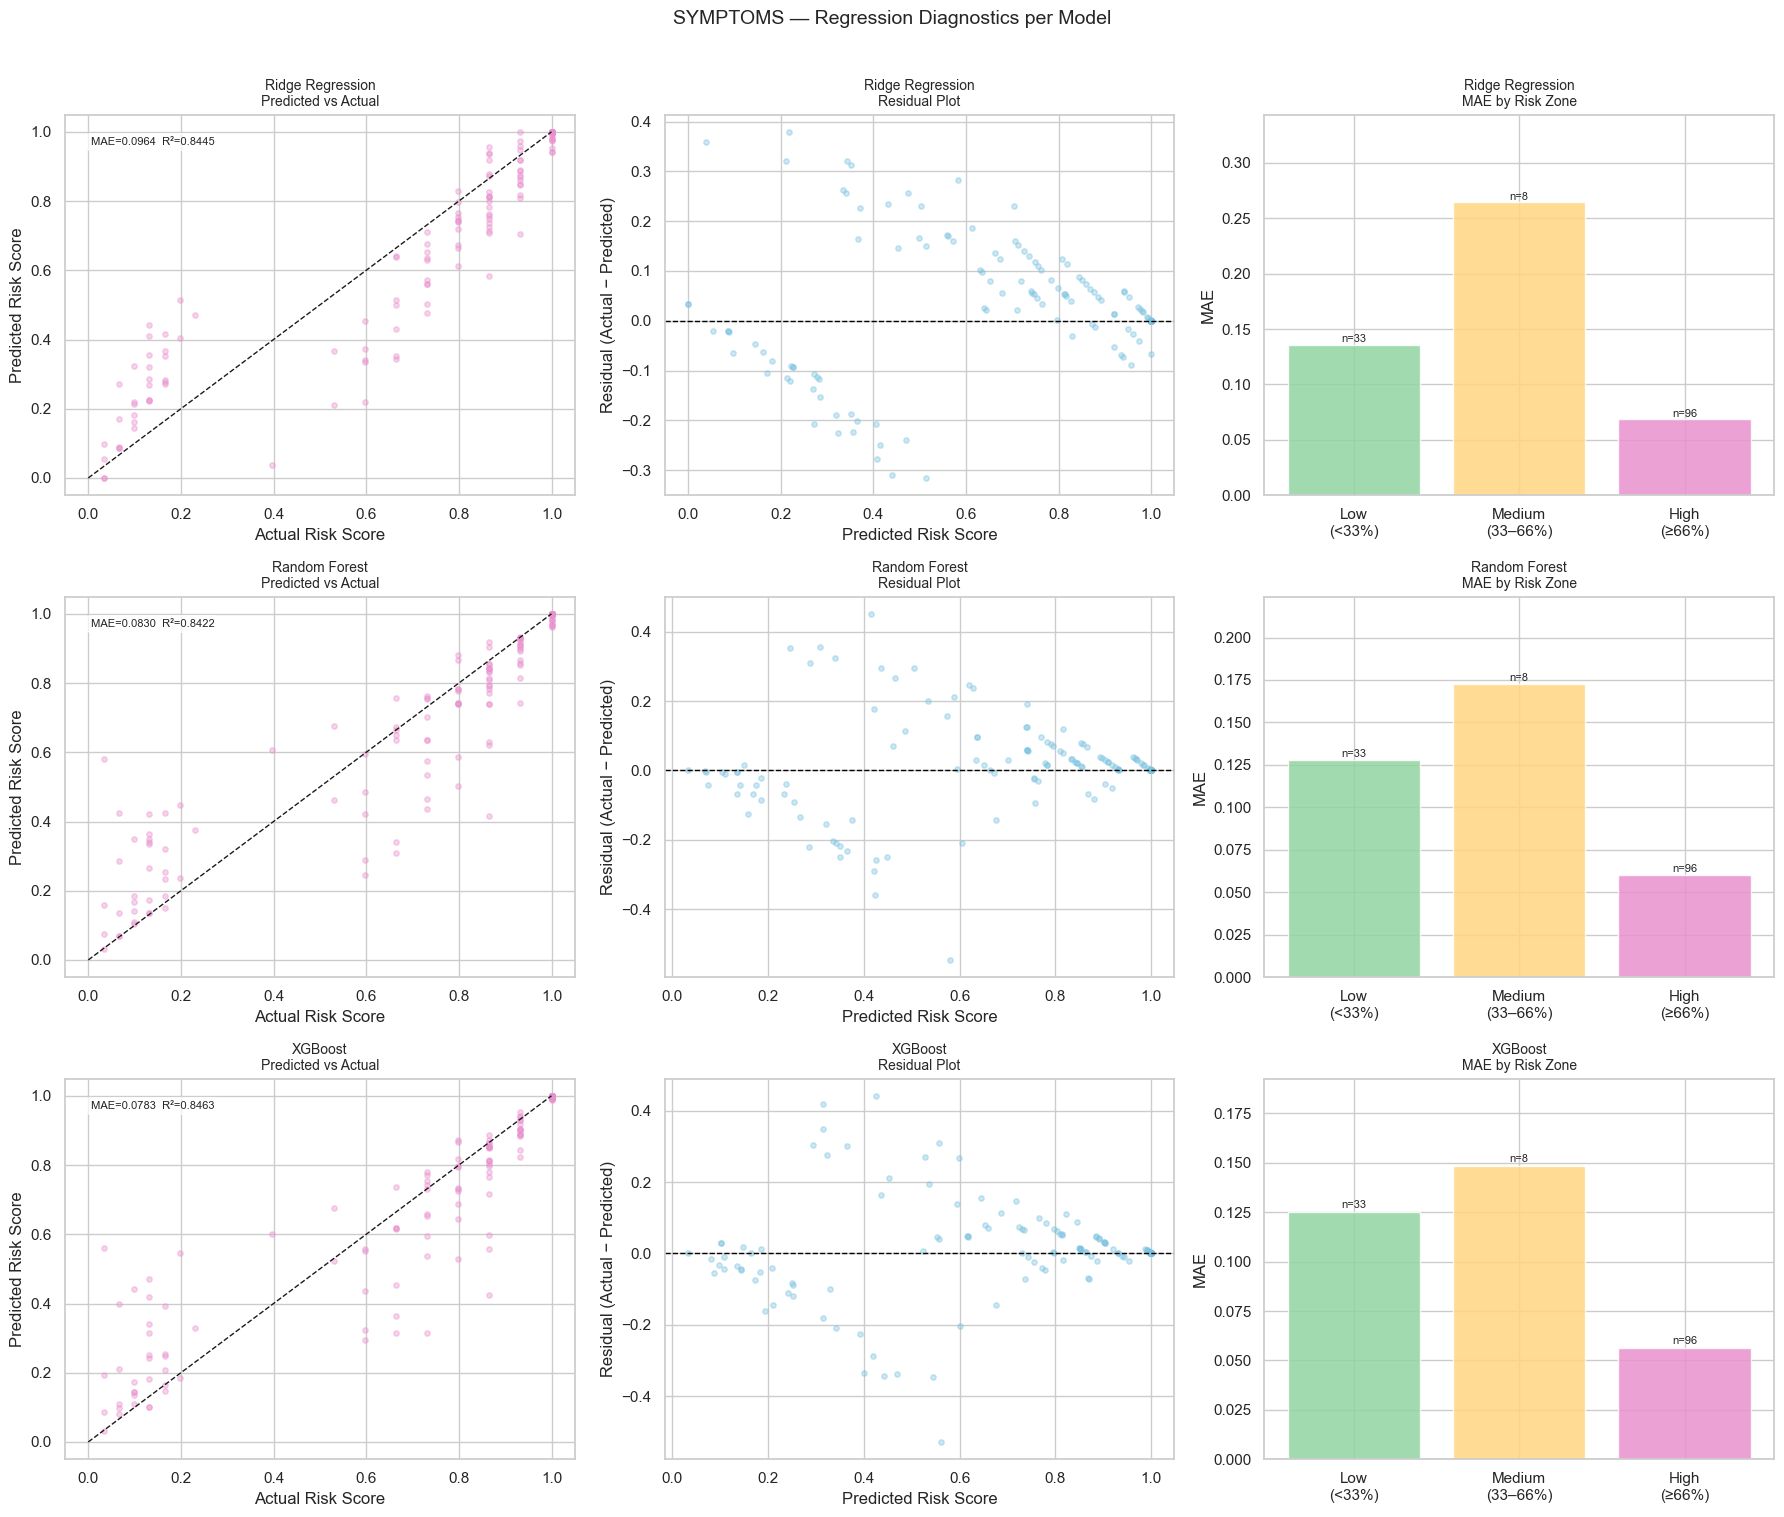

Saved: ../models/symptoms/regression_diagnostics.png


In [4]:
fig, axes = plt.subplots(len(SYM_MODEL_NAMES), 3, figsize=(18, 5 * len(SYM_MODEL_NAMES)))
fig.suptitle("SYMPTOMS — Regression Diagnostics per Model", fontsize=14, y=1.01)

for row_idx, (fname, dname) in enumerate(zip(SYM_MODEL_NAMES, DISPLAY_NAMES_SYM)):
    model  = sym_models[fname]
    y_pred = model.predict(Xs_test).clip(0.0, 1.0)
    resid  = ys_test_score - y_pred

    ax1, ax2, ax3 = axes[row_idx]

    # ── 1. Predicted vs Actual ─────────────────────────────
    ax1.scatter(ys_test_score, y_pred, alpha=0.4, s=15, color="#E991CE")
    ax1.plot([0, 1], [0, 1], "k--", lw=1)
    ax1.set_xlabel("Actual Risk Score")
    ax1.set_ylabel("Predicted Risk Score")
    ax1.set_title(f"{dname}\nPredicted vs Actual", fontsize=10)
    mae = mean_absolute_error(ys_test_score, y_pred)
    r2  = r2_score(ys_test_score, y_pred)
    ax1.text(0.05, 0.92, f"MAE={mae:.4f}  R²={r2:.4f}",
             transform=ax1.transAxes, fontsize=8,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

    # ── 2. Residual plot ───────────────────────────────────
    ax2.scatter(y_pred, resid, alpha=0.4, s=15, color="#7CC3E0")
    ax2.axhline(0, color="black", lw=1, linestyle="--")
    ax2.set_xlabel("Predicted Risk Score")
    ax2.set_ylabel("Residual (Actual − Predicted)")
    ax2.set_title(f"{dname}\nResidual Plot", fontsize=10)

    # ── 3. MAE by zone ─────────────────────────────────────
    zones  = ["Low\n(<33%)", "Medium\n(33–66%)", "High\n(≥66%)"]
    masks  = [ys_test_score < 0.33,
              (ys_test_score >= 0.33) & (ys_test_score < 0.66),
              ys_test_score >= 0.66]
    maes   = [mean_absolute_error(ys_test_score[m], y_pred[m])
              if m.sum() > 0 else 0.0 for m in masks]
    counts = [m.sum() for m in masks]
    bars   = ax3.bar(zones, maes, color=["#90D4A0", "#FFD580", "#E991CE"], alpha=0.85)
    for bar, count in zip(bars, counts):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f"n={count}", ha="center", fontsize=8)
    ax3.set_ylabel("MAE")
    ax3.set_title(f"{dname}\nMAE by Risk Zone", fontsize=10)
    ax3.set_ylim(0, max(maes) * 1.3 if max(maes) > 0 else 0.1)

plt.tight_layout()
plt.savefig("../models/symptoms/regression_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ../models/symptoms/regression_diagnostics.png")

## 4. Symptoms — Predicted Score Distribution

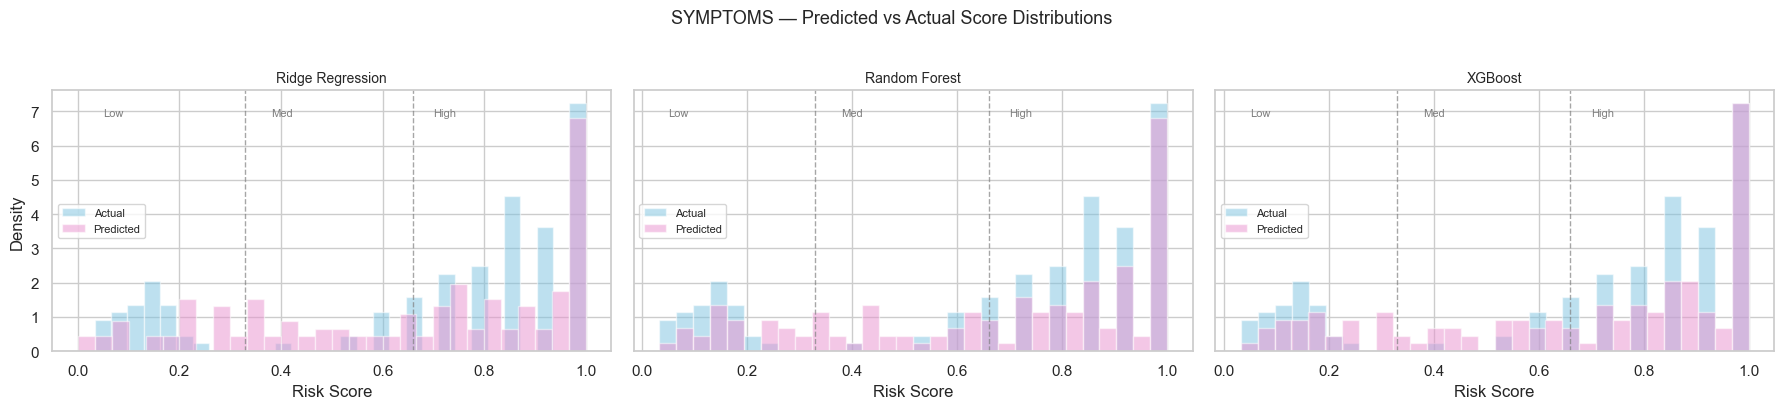

Saved: ../models/symptoms/score_distributions.png


In [5]:
fig, axes = plt.subplots(1, len(SYM_MODEL_NAMES), figsize=(18, 4), sharey=True)
fig.suptitle("SYMPTOMS — Predicted vs Actual Score Distributions", fontsize=13, y=1.02)

for ax, (fname, dname) in zip(axes, zip(SYM_MODEL_NAMES, DISPLAY_NAMES_SYM)):
    model  = sym_models[fname]
    y_pred = model.predict(Xs_test).clip(0.0, 1.0)

    ax.hist(ys_test_score, bins=30, alpha=0.5, color="#7CC3E0",  label="Actual",    density=True)
    ax.hist(y_pred,        bins=30, alpha=0.5, color="#E991CE",  label="Predicted", density=True)

    # Zone dividers
    ax.axvline(0.33, color="gray", lw=1, linestyle="--", alpha=0.7)
    ax.axvline(0.66, color="gray", lw=1, linestyle="--", alpha=0.7)
    ax.text(0.05,  ax.get_ylim()[1]*0.9 if ax.get_ylim()[1] > 0 else 1, "Low",    fontsize=8, color="gray")
    ax.text(0.38,  ax.get_ylim()[1]*0.9 if ax.get_ylim()[1] > 0 else 1, "Med",    fontsize=8, color="gray")
    ax.text(0.70,  ax.get_ylim()[1]*0.9 if ax.get_ylim()[1] > 0 else 1, "High",   fontsize=8, color="gray")

    ax.set_title(dname, fontsize=10)
    ax.set_xlabel("Risk Score")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Density")
plt.tight_layout()
plt.savefig("../models/symptoms/score_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ../models/symptoms/score_distributions.png")

## 5. Clinical — ROC Curves

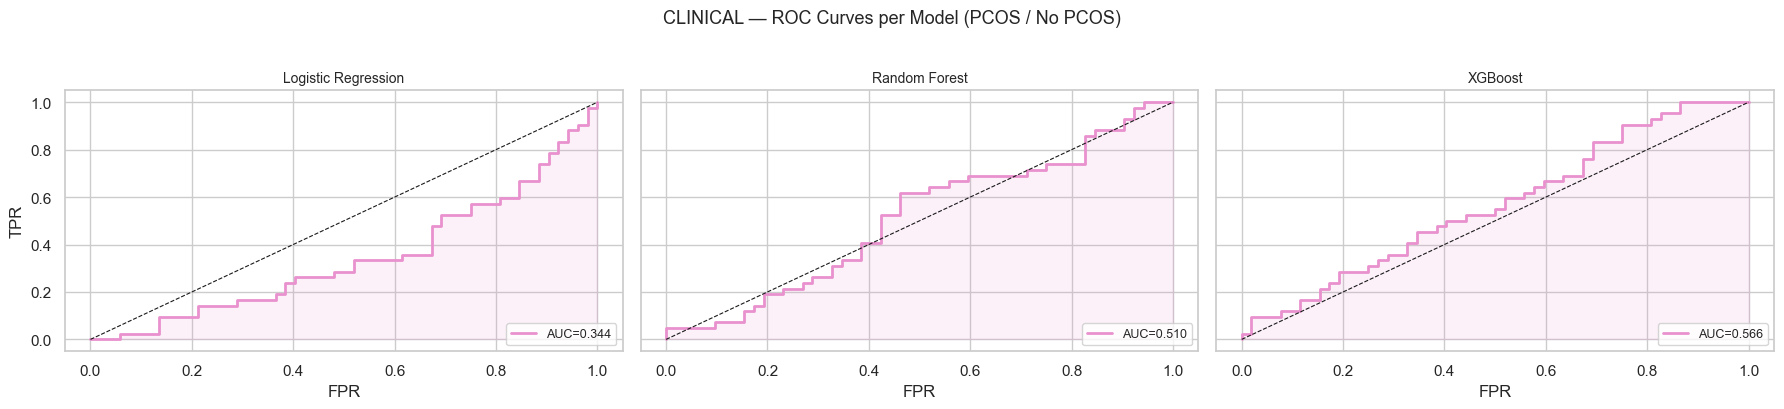

Saved: ../models/clinical/roc_curves.png


In [6]:
fig, axes = plt.subplots(1, len(CLIN_MODEL_NAMES), figsize=(18, 4), sharey=True)
fig.suptitle("CLINICAL — ROC Curves per Model (PCOS / No PCOS)", fontsize=13, y=1.02)

for ax, (fname, dname) in zip(axes, zip(CLIN_MODEL_NAMES, DISPLAY_NAMES_CLIN)):
    model = clin_models[fname]
    proba = model.predict_proba(Xc_test)[:, 1]
    fpr, tpr, _ = roc_curve(yc_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color="#E991CE", lw=2, label=f"AUC={roc_auc:.3f}")
    ax.fill_between(fpr, tpr, alpha=0.12, color="#E991CE")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.set_title(dname, fontsize=10)
    ax.set_xlabel("FPR")
    ax.legend(fontsize=9, loc="lower right")

axes[0].set_ylabel("TPR")
plt.tight_layout()
plt.savefig("../models/clinical/roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ../models/clinical/roc_curves.png")

## 6. Clinical — Confusion Matrix (Best Model)

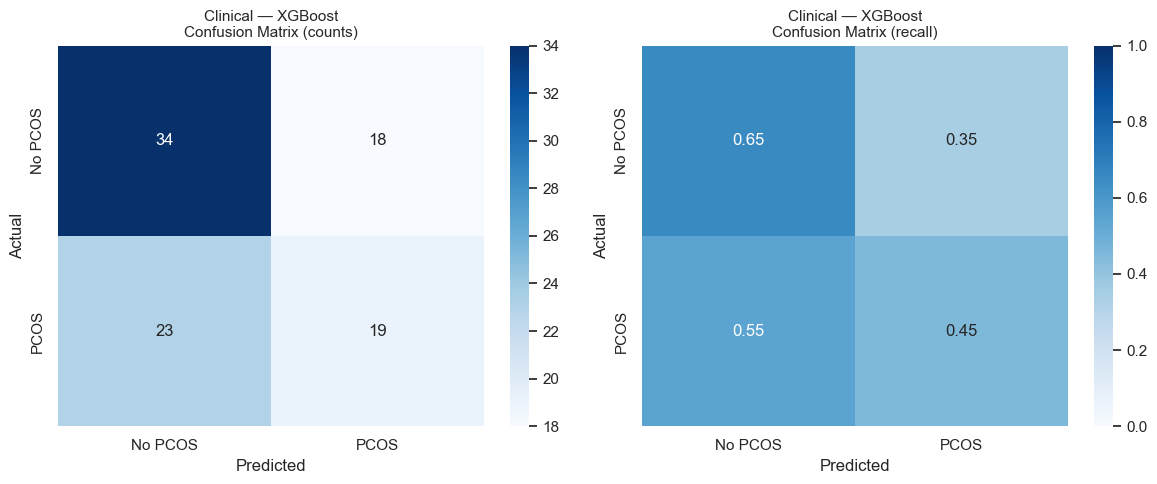

In [7]:
best_clin_name  = clin_summary.sort_values("ROC-AUC", ascending=False).iloc[0]["Model"]
best_clin_fname = best_clin_name.lower().replace(" ", "_")
best_clin_model = clin_models[best_clin_fname]

yc_pred = best_clin_model.predict(Xc_test)
cm_clin = confusion_matrix(yc_test, yc_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_clin, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names_clin, yticklabels=label_names_clin, ax=axes[0])
axes[0].set_title(f"Clinical — {best_clin_name}\nConfusion Matrix (counts)", fontsize=11)
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

cm_norm_c = cm_clin.astype(float) / cm_clin.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm_c, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=label_names_clin, yticklabels=label_names_clin,
            vmin=0, vmax=1, ax=axes[1])
axes[1].set_title(f"Clinical — {best_clin_name}\nConfusion Matrix (recall)", fontsize=11)
axes[1].set_ylabel("Actual")
axes[1].set_xlabel("Predicted")

plt.tight_layout()
plt.savefig("../models/clinical/confusion_matrix_best.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Feature Importance — Symptoms Dataset

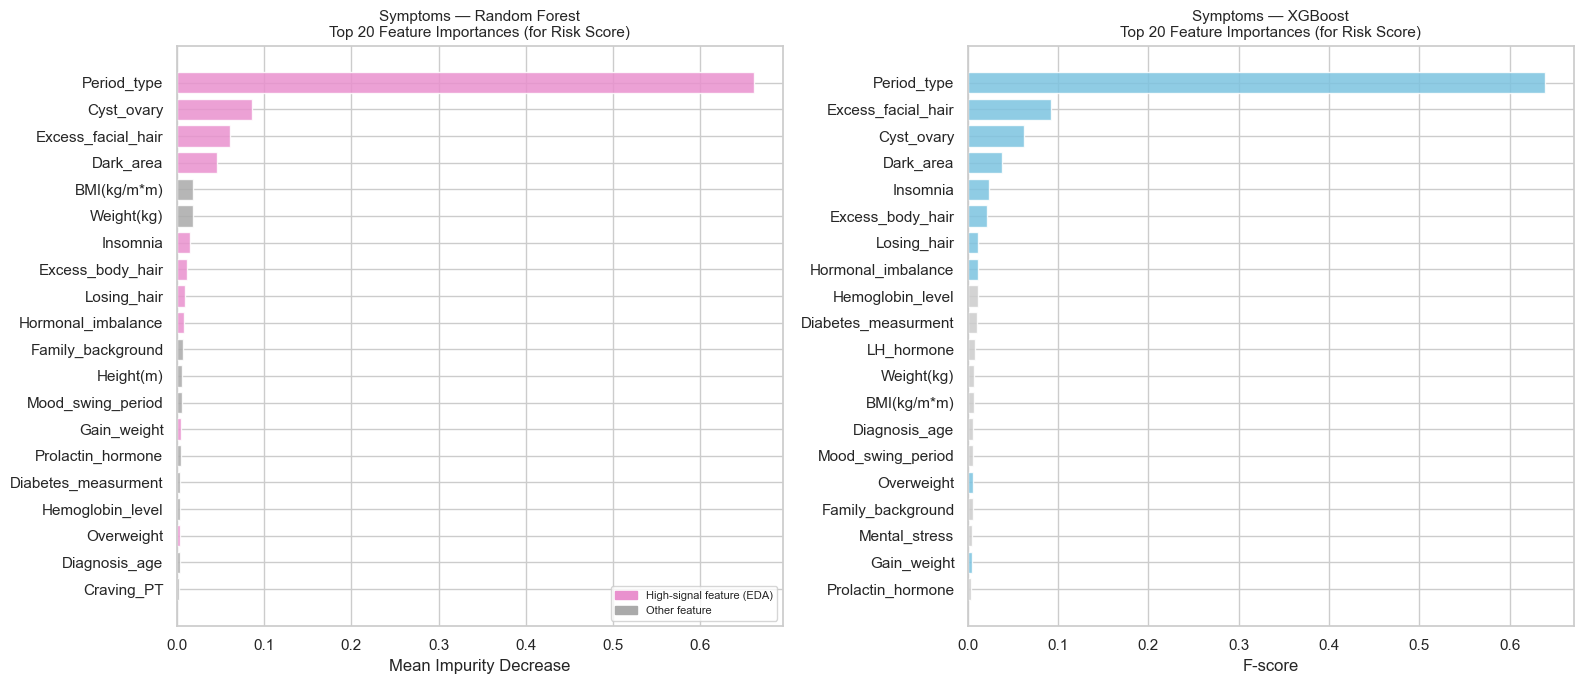


Top 10 symptoms driving PCOS risk score (Random Forest):
   1. Period_type                         0.6616 ★
   2. Cyst_ovary                          0.0867 ★
   3. Excess_facial_hair                  0.0609 ★
   4. Dark_area                           0.0457 ★
   5. BMI(kg/m*m)                         0.0184
   6. Weight(kg)                          0.0181
   7. Insomnia                            0.0155 ★
   8. Excess_body_hair                    0.0123 ★
   9. Losing_hair                         0.0090 ★
  10. Hormonal_imbalance                  0.0082 ★


In [8]:
feature_cols_sym = list(Xs_test.columns)

rf_sym  = sym_models["random_forest"]
xgb_sym = sym_models["xgboost"]

rf_imp  = pd.Series(rf_sym.feature_importances_,  index=feature_cols_sym).sort_values(ascending=False)
xgb_imp = pd.Series(xgb_sym.feature_importances_, index=feature_cols_sym).sort_values(ascending=False)

top_n = 20
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors_rf  = ["#E991CE" if f in HIGH_SIGNAL_COLS else "#AAAAAA" for f in rf_imp.index[:top_n]]
colors_xgb = ["#7CC3E0" if f in HIGH_SIGNAL_COLS else "#CCCCCC" for f in xgb_imp.index[:top_n]]

axes[0].barh(rf_imp.index[:top_n][::-1],  rf_imp.values[:top_n][::-1],
             color=colors_rf[::-1], alpha=0.85)
axes[0].set_title("Symptoms — Random Forest\nTop 20 Feature Importances (for Risk Score)", fontsize=11)
axes[0].set_xlabel("Mean Impurity Decrease")
axes[0].legend(handles=[
    Patch(color="#E991CE", label="High-signal feature (EDA)"),
    Patch(color="#AAAAAA", label="Other feature")
], fontsize=8, loc="lower right")

axes[1].barh(xgb_imp.index[:top_n][::-1], xgb_imp.values[:top_n][::-1],
             color=colors_xgb[::-1], alpha=0.85)
axes[1].set_title("Symptoms — XGBoost\nTop 20 Feature Importances (for Risk Score)", fontsize=11)
axes[1].set_xlabel("F-score")

plt.tight_layout()
plt.savefig("../models/symptoms/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 10 symptoms driving PCOS risk score (Random Forest):")
for i, (feat, val) in enumerate(rf_imp.head(10).items(), 1):
    tag = " ★" if feat in HIGH_SIGNAL_COLS else ""
    print(f"  {i:2d}. {feat:<35} {val:.4f}{tag}")

## 8. Feature Importance — Clinical Dataset

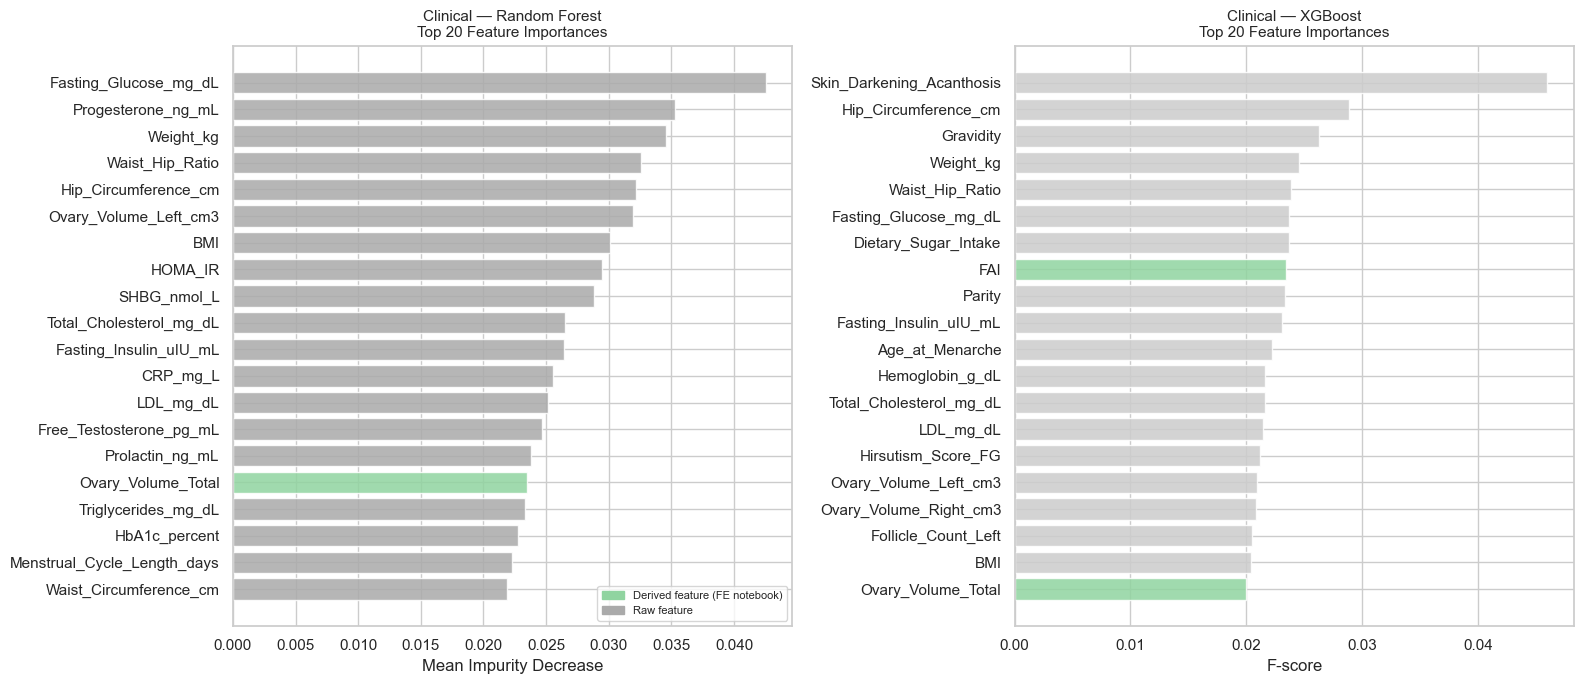


Top 10 clinical features driving PCOS diagnosis (Random Forest):
   1. Fasting_Glucose_mg_dL                    0.0425
   2. Progesterone_ng_mL                       0.0353
   3. Weight_kg                                0.0346
   4. Waist_Hip_Ratio                          0.0326
   5. Hip_Circumference_cm                     0.0322
   6. Ovary_Volume_Left_cm3                    0.0320
   7. BMI                                      0.0301
   8. HOMA_IR                                  0.0294
   9. SHBG_nmol_L                              0.0288
  10. Total_Cholesterol_mg_dL                  0.0265


In [9]:
feature_cols_clin = list(Xc_test.columns)

rf_clin  = clin_models["random_forest"]
xgb_clin = clin_models["xgboost"]

def get_pipeline_importances(pipeline, all_feature_cols):
    """Extract importances from a SelectKBest + classifier pipeline."""
    sel = pipeline.named_steps["sel"]
    clf = pipeline.named_steps["clf"]
    selected = [f for f, m in zip(all_feature_cols, sel.get_support()) if m]
    return pd.Series(clf.feature_importances_, index=selected).sort_values(ascending=False)

rf_imp_c  = get_pipeline_importances(rf_clin,  feature_cols_clin)
xgb_imp_c = get_pipeline_importances(xgb_clin, feature_cols_clin)

DERIVED_COLS = ["FAI", "Follicle_Count_Total", "Ovary_Volume_Total"]

top_n = 20
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors_rf_c  = ["#90D4A0" if f in DERIVED_COLS else "#AAAAAA" for f in rf_imp_c.index[:top_n]]
colors_xgb_c = ["#90D4A0" if f in DERIVED_COLS else "#CCCCCC" for f in xgb_imp_c.index[:top_n]]

axes[0].barh(rf_imp_c.index[:top_n][::-1],  rf_imp_c.values[:top_n][::-1],
             color=colors_rf_c[::-1], alpha=0.85)
axes[0].set_title("Clinical — Random Forest\nTop 20 Feature Importances", fontsize=11)
axes[0].set_xlabel("Mean Impurity Decrease")
axes[0].legend(handles=[
    Patch(color="#90D4A0", label="Derived feature (FE notebook)"),
    Patch(color="#AAAAAA", label="Raw feature")
], fontsize=8, loc="lower right")

axes[1].barh(xgb_imp_c.index[:top_n][::-1], xgb_imp_c.values[:top_n][::-1],
             color=colors_xgb_c[::-1], alpha=0.85)
axes[1].set_title("Clinical — XGBoost\nTop 20 Feature Importances", fontsize=11)
axes[1].set_xlabel("F-score")

plt.tight_layout()
plt.savefig("../models/clinical/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 10 clinical features driving PCOS diagnosis (Random Forest):")
for i, (feat, val) in enumerate(rf_imp_c.head(10).items(), 1):
    tag = " ← derived" if feat in DERIVED_COLS else ""
    print(f"  {i:2d}. {feat:<40} {val:.4f}{tag}")

## 9. Head-to-Head Comparison — All Models, Both Datasets

> **Note:** Symptoms and clinical metrics are not directly comparable — symptoms uses regression metrics (MAE, RMSE, R²) while clinical uses classification metrics (Accuracy, F1, ROC-AUC). They are shown side-by-side for reference only.

SYMPTOMS — Regression Metrics (lower MAE/RMSE, higher R² = better)
           Model    MAE   RMSE     R2
Ridge Regression 0.0964 0.1343 0.8445
   Random Forest 0.0830 0.1352 0.8422
         XGBoost 0.0783 0.1335 0.8463

CLINICAL — Classification Metrics
              Model  Accuracy  F1 Macro  ROC-AUC
            XGBoost    0.5638    0.4810   0.5659
      Random Forest    0.5000    0.3562   0.5101
Logistic Regression    0.3617    0.3617   0.3443


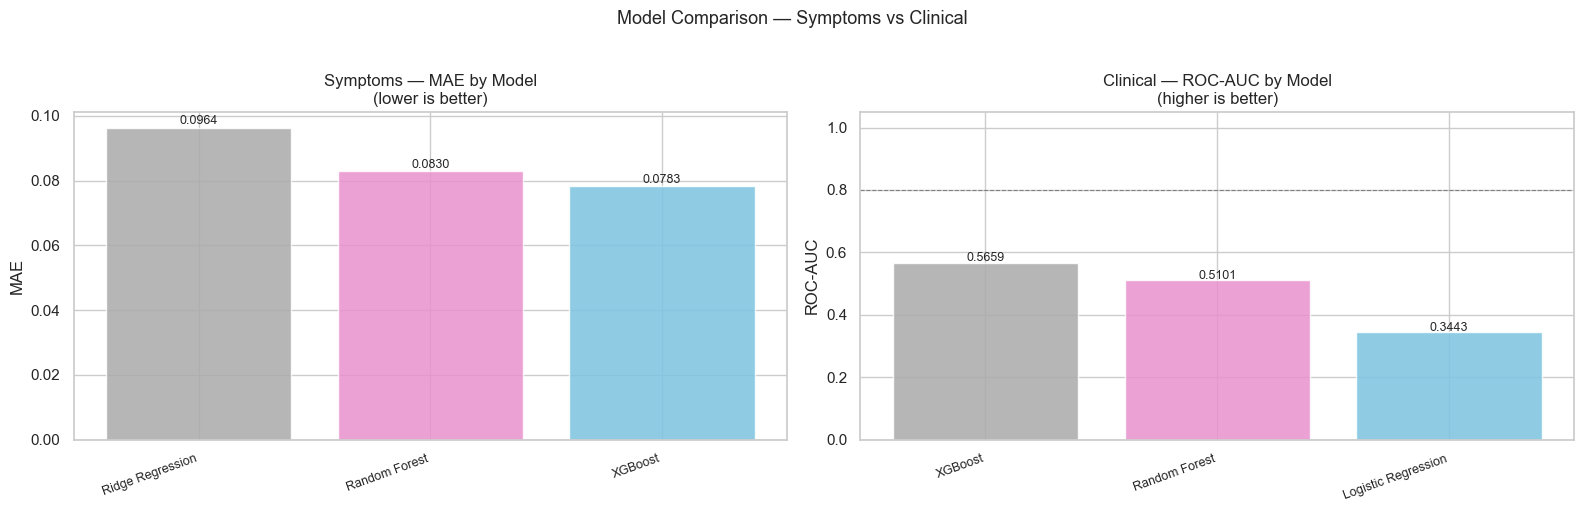

In [10]:
# ── Symptoms: compute regression metrics on test set for display ──────────────
sym_rows = []
for fname, dname in zip(SYM_MODEL_NAMES, DISPLAY_NAMES_SYM):
    model  = sym_models[fname]
    y_pred = model.predict(Xs_test).clip(0.0, 1.0)
    sym_rows.append({
        "Dataset": "Symptoms (Risk Score)",
        "Model":   dname,
        "MAE":     round(mean_absolute_error(ys_test_score, y_pred), 4),
        "RMSE":    round(np.sqrt(mean_squared_error(ys_test_score, y_pred)), 4),
        "R2":      round(r2_score(ys_test_score, y_pred), 4),
    })

sym_compare = pd.DataFrame(sym_rows)

# ── Clinical: use existing summary ────────────────────────────────────────────
clin_compare = clin_summary.copy()
clin_compare["Dataset"] = "Clinical (PCOS/No PCOS)"
clin_compare = clin_compare.rename(columns={"F1 (PCOS)": "F1 Macro"})
clin_compare = clin_compare.loc[:, ~clin_compare.columns.duplicated()]

print("=" * 70)
print("SYMPTOMS — Regression Metrics (lower MAE/RMSE, higher R² = better)")
print("=" * 70)
print(sym_compare[["Model", "MAE", "RMSE", "R2"]].to_string(index=False))

print("\n" + "=" * 70)
print("CLINICAL — Classification Metrics")
print("=" * 70)
print(clin_compare[["Model", "Accuracy", "F1 Macro", "ROC-AUC"]].to_string(index=False))

# ── Visual: two separate bar charts (different scales) ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Symptoms: MAE (lower is better)
palette_sym = {"ridge_regression": "#AAAAAA", "random_forest": "#E991CE", "xgboost": "#7CC3E0"}
axes[0].bar(sym_compare["Model"], sym_compare["MAE"],
            color=["#AAAAAA", "#E991CE", "#7CC3E0"], alpha=0.85)
axes[0].set_title("Symptoms — MAE by Model\n(lower is better)", fontsize=12)
axes[0].set_ylabel("MAE")
axes[0].set_xticklabels(sym_compare["Model"], rotation=20, ha="right", fontsize=9)
for i, v in enumerate(sym_compare["MAE"]):
    axes[0].text(i, v + 0.001, f"{v:.4f}", ha="center", fontsize=9)

# Clinical: ROC-AUC (higher is better)
axes[1].bar(clin_compare["Model"], clin_compare["ROC-AUC"],
            color=["#AAAAAA", "#E991CE", "#7CC3E0"], alpha=0.85)
axes[1].set_title("Clinical — ROC-AUC by Model\n(higher is better)", fontsize=12)
axes[1].set_ylabel("ROC-AUC")
axes[1].set_ylim(0, 1.05)
axes[1].set_xticklabels(clin_compare["Model"], rotation=20, ha="right", fontsize=9)
axes[1].axhline(0.8, color="gray", lw=0.8, linestyle="--")
for i, v in enumerate(clin_compare["ROC-AUC"]):
    axes[1].text(i, v + 0.005, f"{v:.4f}", ha="center", fontsize=9)

plt.suptitle("Model Comparison — Symptoms vs Clinical", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../models/comparison_all_models.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Select Best Models & Save as Final .pkl

In [11]:
# ── Symptoms: best = lowest MAE ──────────────────────────────────────────────
best_sym_row   = sym_compare.sort_values("MAE", ascending=True).iloc[0]
best_sym_fname = best_sym_row["Model"].lower().replace(" ", "_")
best_sym_model = sym_models[best_sym_fname]

# ── Clinical: best = highest ROC-AUC, tiebreak F1 Macro ──────────────────────
best_clin_row   = clin_summary.sort_values(["ROC-AUC", "F1 Macro"], ascending=False).iloc[0]
best_clin_fname = best_clin_row["Model"].lower().replace(" ", "_")
best_clin_model = clin_models[best_clin_fname]

print("══ SELECTED MODELS ══")
print(f"  Symptoms → {best_sym_row['Model']}")
print(f"    MAE={best_sym_row['MAE']}  RMSE={best_sym_row['RMSE']}  R²={best_sym_row['R2']}")
print()
print(f"  Clinical → {best_clin_row['Model']}")
print(f"    Accuracy={best_clin_row['Accuracy']}  F1 Macro={best_clin_row['F1 Macro']}  ROC-AUC={best_clin_row['ROC-AUC']}")

# ── Save final production models ───────────────────────────
joblib.dump(best_sym_model,  "../models/best_symptoms_model.pkl")
joblib.dump(best_clin_model, "../models/best_clinical_model.pkl")

# ── Save selection metadata (for FastAPI model loader) ────────────────────────
selection_meta = {
    "symptoms": {
        "model_name":    best_sym_row["Model"],
        "task":          "risk_score_regression",      # continuous 0–1 output
        "output_type":   "regression",
        "score_range":   [0.0, 1.0],
        "thresholds":    risk_meta["thresholds"],       # {"low": 0.33, "medium": 0.66}
        "label_names":   risk_meta["label_names"],
        "metric_used":   "MAE (lower is better)",
        "mae":           float(best_sym_row["MAE"]),
        "rmse":          float(best_sym_row["RMSE"]),
        "r2":            float(best_sym_row["R2"]),
    },
    "clinical": {
        "model_name":    best_clin_row["Model"],
        "task":          "binary_pcos_diagnosis",
        "output_type":   "classification",
        "classes":       ["No PCOS", "PCOS"],
        "n_classes":     2,
        "metric_used":   "ROC-AUC",
        "roc_auc":       float(best_clin_row["ROC-AUC"]),
        "f1_macro":      float(best_clin_row["F1 Macro"]),
        "accuracy":      float(best_clin_row["Accuracy"]),
    }
}
joblib.dump(selection_meta, "../models/selection_meta.pkl")

print("\nSaved:")
print("  ../models/best_symptoms_model.pkl")
print("  ../models/best_clinical_model.pkl")
print("  ../models/selection_meta.pkl")

══ SELECTED MODELS ══
  Symptoms → XGBoost
    MAE=0.0783  RMSE=0.1335  R²=0.8463

  Clinical → XGBoost
    Accuracy=0.5638  F1 Macro=0.5524  ROC-AUC=0.5659

Saved:
  ../models/best_symptoms_model.pkl
  ../models/best_clinical_model.pkl
  ../models/selection_meta.pkl


## 11. Final Summary

In [13]:
print("""╔══════════════════════════════════════════════════════════════╗
║              STEP 7 — MODEL EVALUATION COMPLETE              ║
╠══════════════════════════════════════════════════════════════╣
║  SYMPTOMS DATASET                                            ║
║  Task   : Continuous Risk Score → displayed as 0–100 %       ║""")
print(f"║  Winner : {best_sym_row['Model']:<50} ║")
print(f"║  MAE    : {best_sym_row['MAE']:<50} ║")
print(f"║  R²     : {best_sym_row['R2']:<50} ║")
print("""╠══════════════════════════════════════════════════════════════╣
║  CLINICAL DATASET                                            ║
║  Task   : PCOS / No PCOS (binary)                            ║""")
print(f"║  Winner : {best_clin_row['Model']:<50} ║")
print(f"║  ROC-AUC: {best_clin_row['ROC-AUC']:<50} ║")
print(f"║  F1 Mac : {best_clin_row['F1 Macro']:<50} ║")
print("""╠══════════════════════════════════════════════════════════════╣
║  INFERENCE — Symptoms model output example:                  ║
║    raw_score = model.predict(X_new)[0].clip(0, 1)            ║
║    pct       = round(raw_score * 100, 1)   # e.g. 73.4 %     ║
║    label     = score_to_label(raw_score)   # "High Risk"     ║
╠══════════════════════════════════════════════════════════════╣
║  SAVED ARTIFACTS                                             ║
║  best_symptoms_model.pkl  → FastAPI symptoms endpoint        ║
║  best_clinical_model.pkl  → FastAPI clinical endpoint        ║
║  selection_meta.pkl       → model metadata for API           ║
╚══════════════════════════════════════════════════════════════╝""")

╔══════════════════════════════════════════════════════════════╗
║              STEP 7 — MODEL EVALUATION COMPLETE              ║
╠══════════════════════════════════════════════════════════════╣
║  SYMPTOMS DATASET                                            ║
║  Task   : Continuous Risk Score → displayed as 0–100 %       ║
║  Winner : XGBoost                                            ║
║  MAE    : 0.0783                                             ║
║  R²     : 0.8463                                             ║
╠══════════════════════════════════════════════════════════════╣
║  CLINICAL DATASET                                            ║
║  Task   : PCOS / No PCOS (binary)                            ║
║  Winner : XGBoost                                            ║
║  ROC-AUC: 0.5659                                             ║
║  F1 Mac : 0.5524                                             ║
╠══════════════════════════════════════════════════════════════╣
║  INFERENCE — Symptoms m